In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestRegressor

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

In [3]:
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score , classification_report

In [4]:
import torch

torch.set_num_threads(4)

In [5]:
import torch

print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print("CUDA version:", torch.version.cuda)
print("GPU count:", torch.cuda.device_count())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

PyTorch version: 2.11.0+cu128
CUDA available: True
CUDA version: 12.8
GPU count: 1
GPU: NVIDIA GeForce RTX 4060 Laptop GPU


In [6]:
import torch

print(torch.__version__)
print(torch.version.cuda)
print(torch.cuda.is_available())

2.11.0+cu128
12.8
True


In [7]:
%pip uninstall torch torchvision torchaudio -y

Found existing installation: torch 2.11.0+cu128
Uninstalling torch-2.11.0+cu128:
  Successfully uninstalled torch-2.11.0+cu128
Found existing installation: torchvision 0.26.0+cu128
Uninstalling torchvision-0.26.0+cu128:
  Successfully uninstalled torchvision-0.26.0+cu128
Found existing installation: torchaudio 2.11.0+cu128
Uninstalling torchaudio-2.11.0+cu128:
  Successfully uninstalled torchaudio-2.11.0+cu128
Note: you may need to restart the kernel to use updated packages.


You can safely remove it manually.


In [8]:
%pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu128

Looking in indexes: https://download.pytorch.org/whl/cu128
  Using cached torch-2.11.0%2Bcu128-cp311-cp311-win_amd64.whl.metadata (29 kB)
  Using cached torchvision-0.26.0%2Bcu128-cp311-cp311-win_amd64.whl.metadata (5.6 kB)
  Using cached torchaudio-2.11.0%2Bcu128-cp311-cp311-win_amd64.whl.metadata (7.0 kB)
Using cached torch-2.11.0%2Bcu128-cp311-cp311-win_amd64.whl (2753.1 MB)
Using cached torchvision-0.26.0%2Bcu128-cp311-cp311-win_amd64.whl (9.3 MB)
Using cached torchaudio-2.11.0%2Bcu128-cp311-cp311-win_amd64.whl (1.7 MB)

   ---------------------------------------- 0/3 [torchaudio]
   ------------- -------------------------- 1/3 [torch]
   ------------- -------------------------- 1/3 [torch]
   ------------- -------------------------- 1/3 [torch]
   ------------- -------------------------- 1/3 [torch]
   ------------- -------------------------- 1/3 [torch]
   ------------- -------------------------- 1/3 [torch]
   ------------- -------------------------- 1/3 [torch]
   -------------

In [9]:
from transformers import AutoTokenizer , AutoModel

c:\Users\sumit\AppData\Local\Programs\Python\Python311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [10]:
train = pd.read_csv(
    "twitter_training.csv",
    names = ["id" , "entity" , "sentiment" , "text"]
    )
val = pd.read_csv(
    "twitter_validation.csv",
    names = ["id" , "entity" , "sentiment" , "text"]
    )

In [11]:
print(f"Train Shape : {train.shape}")
print(f"Validation Shape : {val.shape}")

Train Shape : (74682, 4)
Validation Shape : (1000, 4)


In [12]:
train.head()

,id,entity,sentiment,text
0,2401,Borderlands,Positive,im getting on borderlands and i will murder yo...
1,2401,Borderlands,Positive,I am coming to the borders and I will kill you...
2,2401,Borderlands,Positive,im getting on borderlands and i will kill you ...
3,2401,Borderlands,Positive,im coming on borderlands and i will murder you...
4,2401,Borderlands,Positive,im getting on borderlands 2 and i will murder ...


In [13]:
val.head()

,id,entity,sentiment,text
0,3364,Facebook,Irrelevant,I mentioned on Facebook that I was struggling ...
1,352,Amazon,Neutral,BBC News - Amazon boss Jeff Bezos rejects clai...
2,8312,Microsoft,Negative,@Microsoft Why do I pay for WORD when it funct...
3,4371,CS-GO,Negative,"CSGO matchmaking is so full of closet hacking,..."
4,4433,Google,Neutral,Now the President is slapping Americans in the...


In [14]:
sentiment_count = train["sentiment"].value_counts()
sentiment_count

sentiment
Negative      22542
Positive      20832
Neutral       18318
Irrelevant    12990
Name: count, dtype: int64

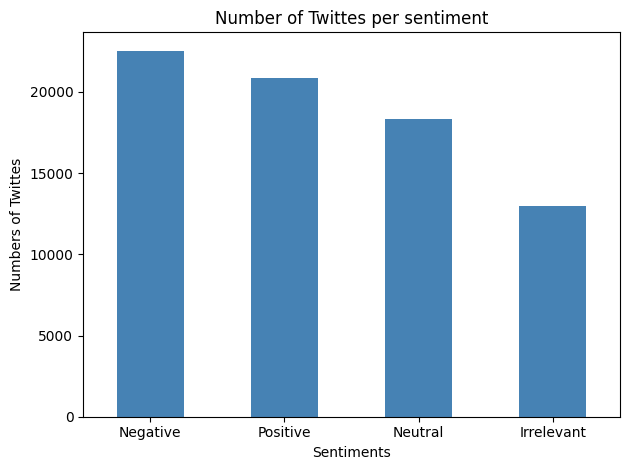

In [15]:
sentiment_count.plot(kind="bar" ,  color="steelblue")
plt.title("Number of Twittes per sentiment")
plt.xlabel("Sentiments")
plt.ylabel("Numbers of Twittes")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [33]:
# Removing Rows where Text is missing
train_df = train.dropna(subset=["text"])
val_df = val.dropna(subset=["text"])

# make sure that each text is string
train_df["text"] = train_df["text"].astype(str)
val_df["text"] = val_df["text"].astype(str)

# keep only positive and negative tweets , drop Neutral and Irrelevent
labels_to_keep = ["Positive" , "Negative"]

train_df = train_df[ train_df["sentiment"].isin(labels_to_keep) ]
test_df = val_df[ val_df["sentiment"].isin(labels_to_keep) ]

print(f"Training Rows after Cleaning : {train_df.shape}")
print(f"Validation Rows after Cleaning : {val_df.shape}")

Training Rows after Cleaning : (43013, 4)
Validation Rows after Cleaning : (1000, 4)


In [17]:
train_df["sentiment"].value_counts()

sentiment
Negative    22358
Positive    20655
Name: count, dtype: int64

In [34]:
train_sample = train_df.sample(n=30000 , random_state=42)
test_sample = test_df

print(f"train_sample : {train_sample.shape}")
print(f"test_sample : {test_sample.shape}")

train_sample : (30000, 4)
test_sample : (543, 4)


### BERT -> bert-base-uncased

In [28]:
tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")
bert_model = AutoModel.from_pretrained("bert-base-uncased")

# use GPU if one is available , otherwise use CPU
device = "cuda" if torch.cuda.is_available() else "cpu"
bert_model = bert_model.to(device)

# put the model in evaluation mode because we are not training BERT
bert_model.eval()

print("BERT is loaded and running on :",  device)

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 6508.07it/s]
[transformers] BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


BERT is loaded and running on : cuda


#### Generate Embeddings

In [29]:
# This function takes a list of texts and returns their BERT embeddings

def get_embeddings(texts, batch_size=32):

    all_embeddings = []

    # Go through the texts a few at a time
    for start in range(0, len(texts), batch_size):

        batch = texts[start:start + batch_size]

        # Convert words into token numbers that BERT understands
        tokens = tokenizer(
            batch,
            padding=True,
            truncation=True,
            max_length=64,
            return_tensors="pt"
        )

        # Move tokens to GPU
        tokens = {key: value.to(device) for key, value in tokens.items()}

        # Ask BERT to read the tokens without training/updating BERT
        with torch.no_grad():

            output = bert_model(**tokens)

        # Take the CLS token as the representation of the whole text
        cls_vectors = output.last_hidden_state[:, 0, :]

        # Move embeddings from GPU to CPU and convert to NumPy
        cls_vectors = cls_vectors.cpu().numpy()

        # Store this batch
        all_embeddings.append(cls_vectors)

    # Combine all batches into one NumPy array
    embeddings = np.vstack(all_embeddings)

    return embeddings

In [30]:
train_texts = train_sample["text"].tolist()
test_texts = test_sample["text"].tolist()

X_train = get_embeddings(train_texts)

X_test = get_embeddings(test_texts)

print(f"Shape of traning embeddings : {X_train.shape}")
print(f"Shape of testing embeddings : {X_test.shape}")

Shape of traning embeddings : (30000, 768)
Shape of testing embeddings : (1000, 768)


In [35]:
label_encoder = LabelEncoder()
label_encoder.fit(train_sample["sentiment"])

# turn the sentiment words into numbers
y_train = label_encoder.transform(train_sample["sentiment"])
y_test = label_encoder.transform(test_sample["sentiment"])

# show which number stands for which sentiment
print("Label mapping:")
for number, name in enumerate(label_encoder.classes_):
    print(number, "->", name)

Label mapping:
0 -> Negative
1 -> Positive


In [36]:
X_train[:5]

array([[ 0.14683048,  0.15640084,  0.10718698, ..., -0.37484866,
         0.48272192,  0.61913246],
       [-0.13488236, -0.2893719 ,  0.49753746, ..., -0.38087222,
         0.3861095 ,  0.30871555],
       [-0.02634625,  0.03419616, -0.40358147, ..., -0.34606272,
         0.43117264,  0.38534072],
       [-0.1864568 , -0.06916929, -0.0527474 , ..., -0.38971758,
         0.28725106,  0.2683801 ],
       [-0.06821168,  0.02091833,  0.1861624 , ..., -0.13078217,
         0.47197074,  0.32003003]], shape=(5, 768), dtype=float32)